<a href="https://colab.research.google.com/github/Ipsita20262005/Diabetes_Prediction_Using_Machine_Learning/blob/main/Pima_diabetes_predction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)



Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as skl
#from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing



In [ ]:
#Exclude the header always or it will create issue while calculation
column_names = ['pregnant', 'glucose', ' bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
data_set=pd.read_csv("diabetes.csv", header=None, names=column_names, skiprows=(0,0))






In [ ]:
data_set.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2    bp       768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   bmi       768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#data_frame.describe
data_set.describe()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#conversion of string to numeric
convert_col = ['pregnant', 'insulin', 'bmi','age','glucose', ' bp', 'pedigree']
for col in convert_col:
    data_set[col] = pd.to_numeric(data_set[col])

In [ ]:
#feature selection
features_columns = ['pregnant', 'insulin', 'bmi','age','glucose', ' bp', 'pedigree']
X = data_set[features_columns]
y = data_set.label
#x.descibe()

Text(0.5, 300.7222222222222, 'Feature Values on X axis')

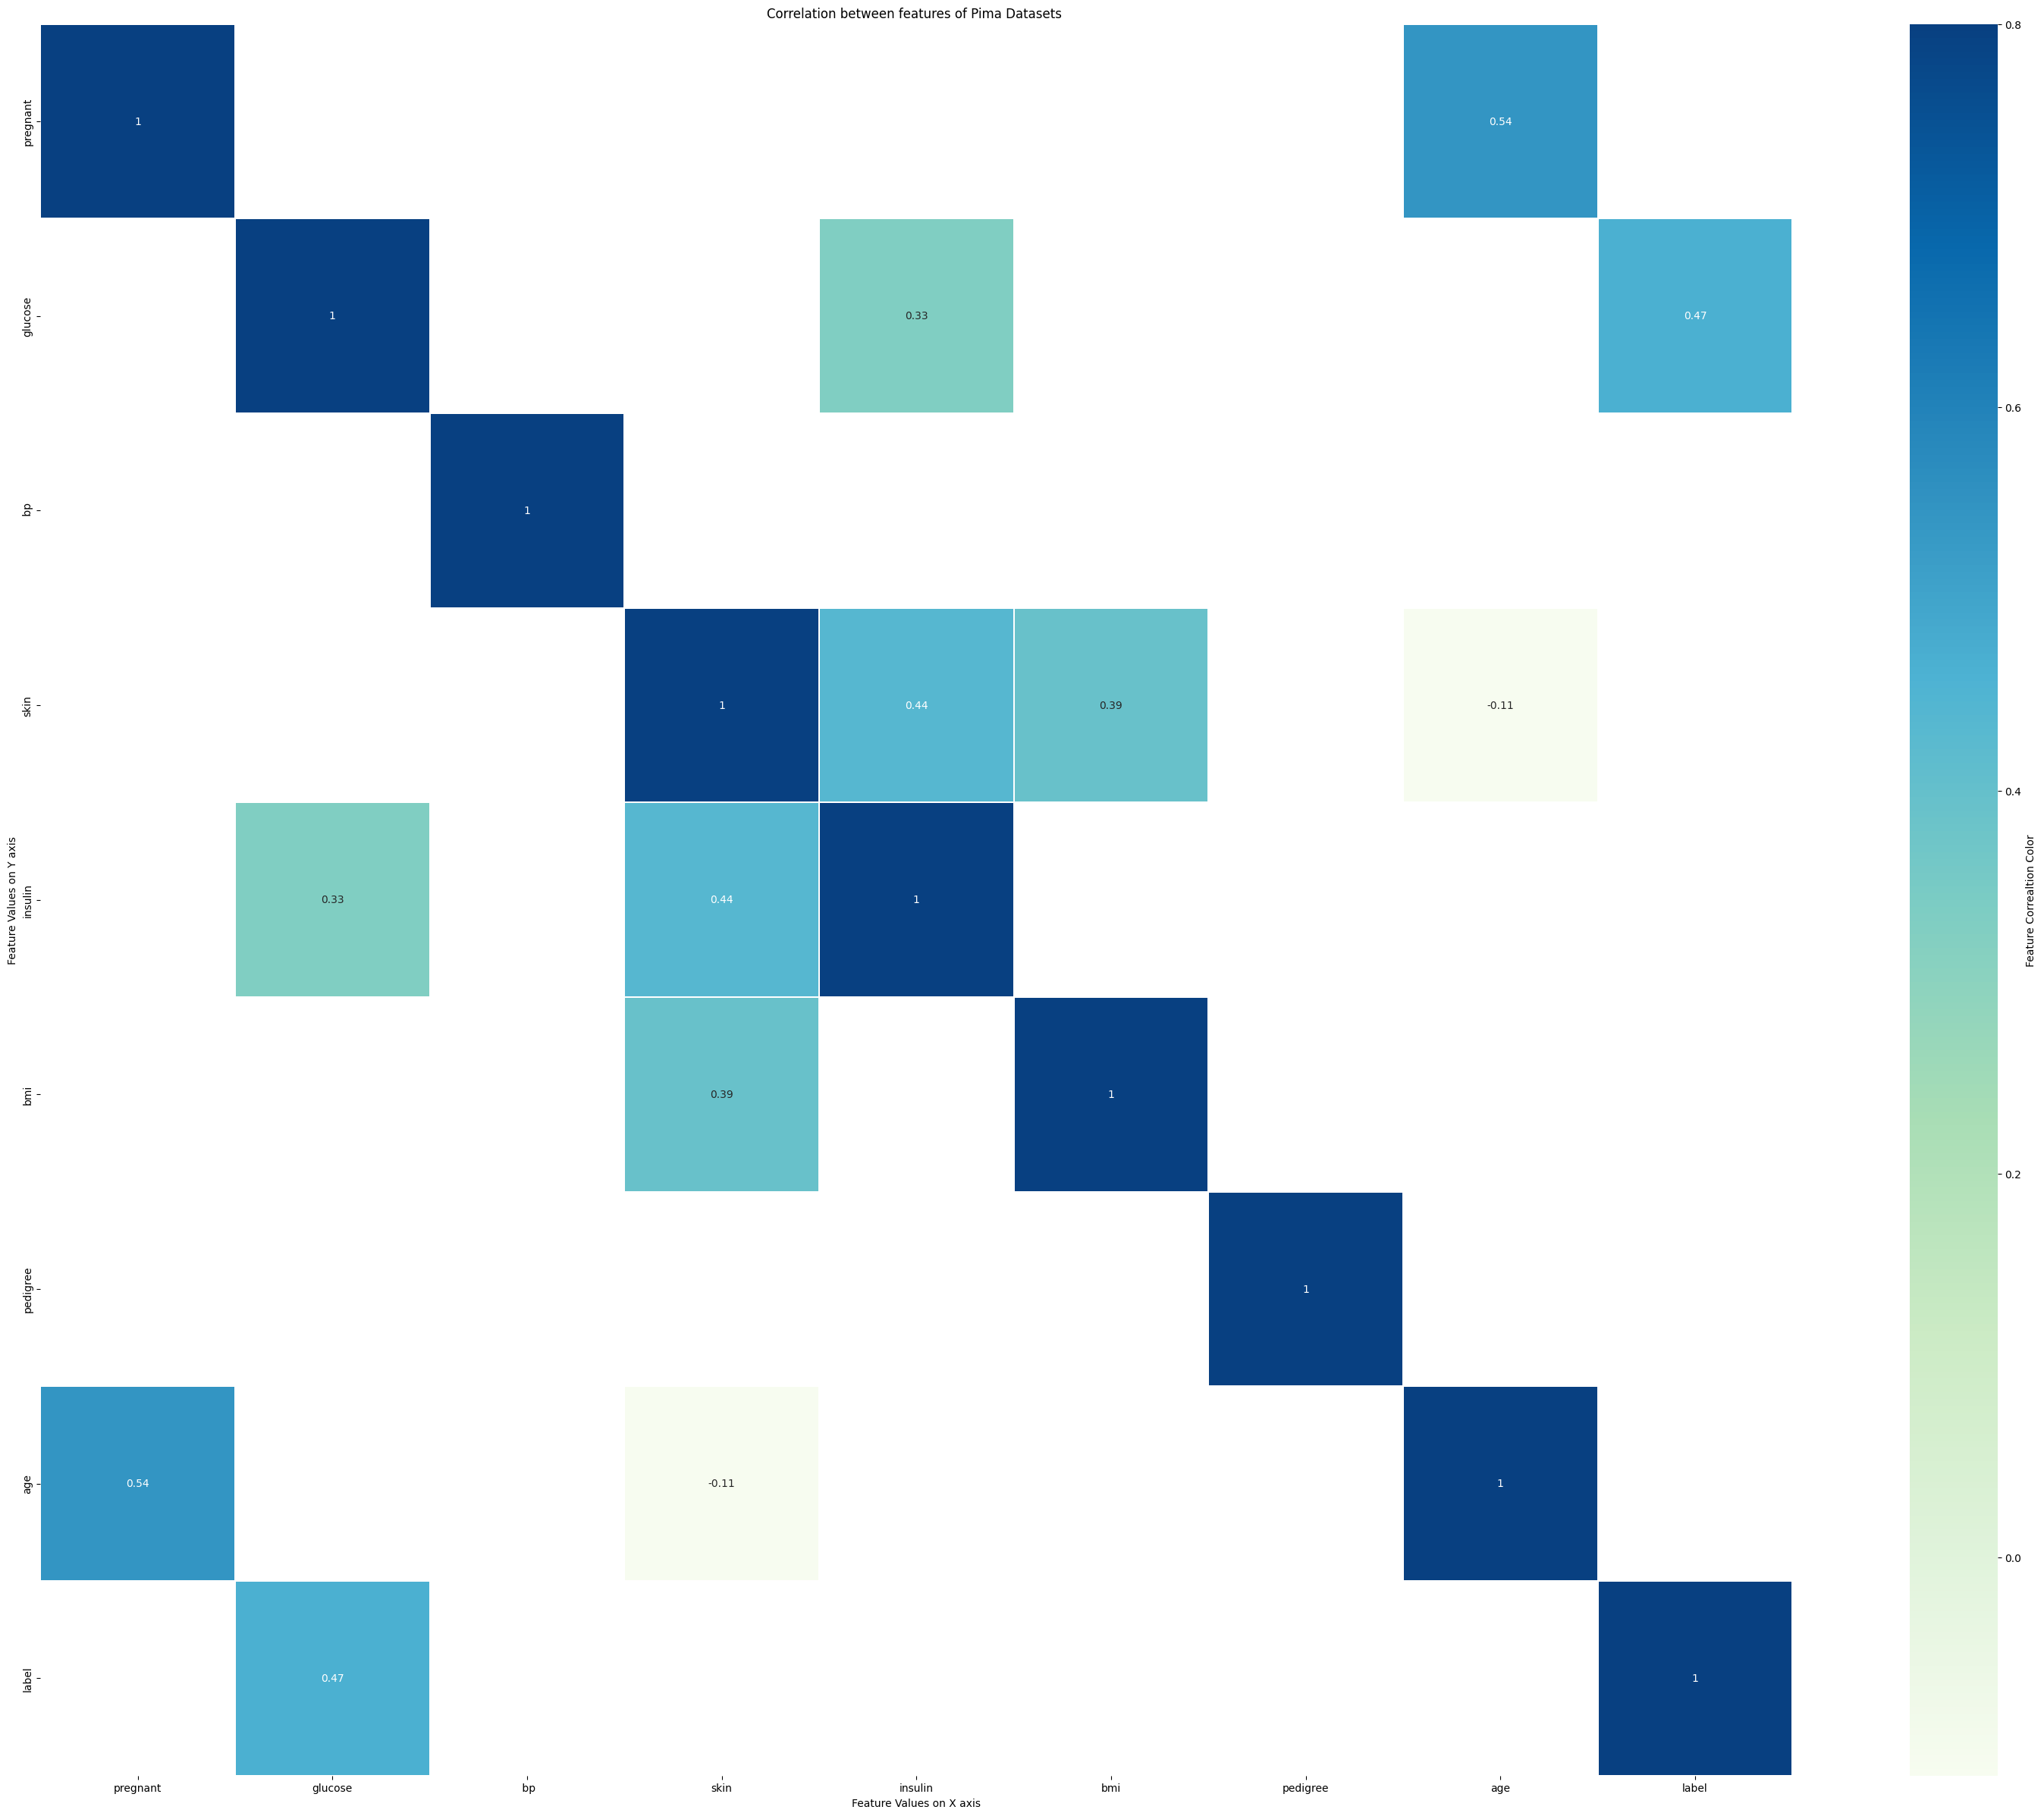

In [ ]:

#checking corelation and correlation plot
corr=data_set.corr()
plt.figure(figsize=(40,30))




coor_range = corr[(corr >= 0.3) | (corr <= -0.1)]
sns.heatmap( coor_range, vmax = .8 , linewidths=0.1, square=True,annot=True,cmap= 'GnBu', linecolor="white",cbar_kws={'label': 'Feature Correaltion Color'})
plt.title('Correlation between features of Pima Datasets ')
plt.ylabel("Feature Values on Y axis")
plt.xlabel("Feature Values on X axis")


In [ ]:
#splitting the dataset into test and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
#applying the Logistic Regression algorithm
logistic_function = LogisticRegression()

In [ ]:
# Fit the model with the training data
logistic_function.fit(X_train, y_train)
y_prediction=logistic_function.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Model Evaluation using Confusion matrix for the performance of classification model
from sklearn import metrics
cnf_matrix_evaluation = metrics.confusion_matrix(y_test, y_prediction)
cnf_matrix_evaluation

array([[79, 20],
       [19, 36]])

In [ ]:
#visualization of confusion matrix using heatmap
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 427.9555555555555, 'Predicted label')

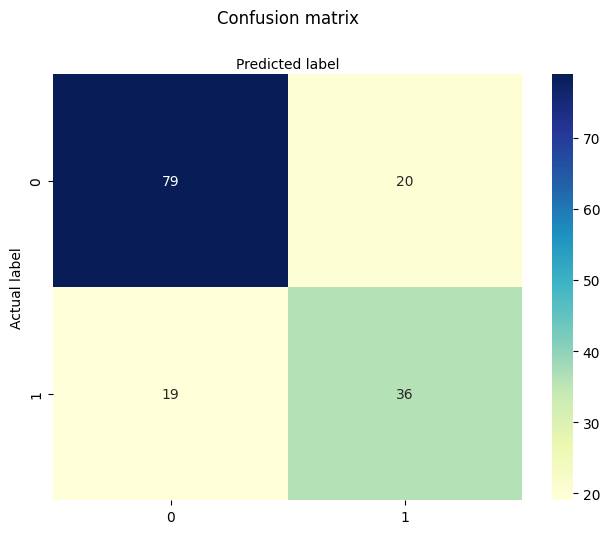

In [ ]:
class_names = [0,1] #naming the classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

#creating the heatmap for getting the confusion matrix
sns.heatmap(pd.DataFrame(cnf_matrix_evaluation), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
#confusion Matrix conclusion for the evaluation matrix
print("Accuracy:",metrics.accuracy_score(y_test, y_prediction))
print("Precision:",metrics.precision_score(y_test, y_prediction))
print("Recall:",metrics.recall_score(y_test, y_prediction))
print(metrics.accuracy_score(y_test, y_prediction)*100 , "% :", "chances that the person having diabetes in the present dataset")
print(y_prediction)

Accuracy: 0.7467532467532467
Precision: 0.6428571428571429
Recall: 0.6545454545454545
74.67532467532467 % : chances that the person having diabetes in the present dataset
[0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 1 1 0 1 1 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


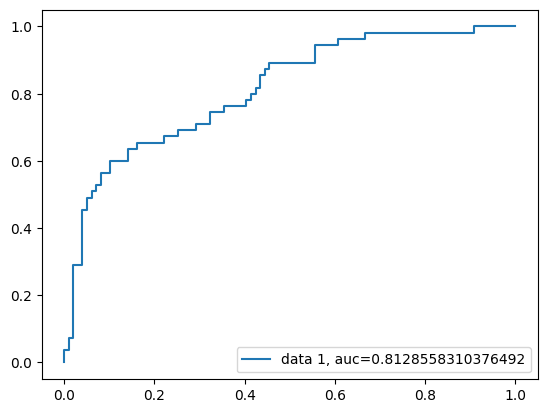

In [ ]:
#performance evaluation using ROC curve, Receiver Operating Characteristic(ROC) curve is a plot of the true positive rate
#it shows the tradeoff between sensitivity and specificity.
y_prediction_probability = logistic_function.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_prediction_probability)
auc = metrics.roc_auc_score(y_test, y_prediction_probability)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
#f1_score(y_test, y_prediction, average ='weihted')
f1_score(y_test, y_prediction, average=None)
#f1_score(y_test, y_prediction, average ='macro')

array([0.80203046, 0.64864865])